<a href="https://colab.research.google.com/github/BrendJ510/Proyectos-Escolares/blob/main/Copia_de_Emotion_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PART 1. FACIAL KEY EXPRESSIONS**

## **TASK #1: LOAD PACKAGES AND DATA**

In [ ]:
# Mount the drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cd /content/drive/My\ Drive/Colab Notebooks/Modern AI Portfolio/Emotion AI

[Errno 2] No such file or directory: '/content/drive/My Drive/Colab Notebooks/Modern AI Portfolio/Emotion AI'
/content


In [ ]:
!pip install opencv-python-headless

In [ ]:
!pip install -U tensorflow tensorflow-cpu keras==3.0.5

INFO: pip is looking at multiple versions of tensorflow to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of tensorflow to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.9 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of tensorflow-cpu to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.8/590.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.2/214.2 MB 5.2 MB/s et

In [ ]:
# ================================
# 1. Librerías científicas básicas
# ================================
import numpy as np
import pandas as pd
import os
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

# ========================================
# 2. Librerías de TensorFlow / Keras (tf.keras)
# ========================================
import tensorflow as tf

from tensorflow.keras.models import Model, load_model
from tensorflow.keras.initializers import glorot_uniform
from tensorflow.keras.callbacks import (
    ReduceLROnPlateau, EarlyStopping, ModelCheckpoint, LearningRateScheduler
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import plot_model

# Capas de Keras
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, Activation,
    MaxPooling2D, AveragePooling2D, ZeroPadding2D,
    Add, Flatten, Dense, Dropout
)

# Utilidades internas
from tensorflow.keras import backend as K
from tensorflow.keras import optimizers

# ============================================
# 3. Sklearn (solo para splits / métricas, si es necesario)
# ============================================
from sklearn.model_selection import train_test_split

# ============================================
# 4. Herramientas de Colab
# ============================================
from google.colab.patches import cv2_imshow


In [ ]:
# Load Facial Key Points Data
keyfacial_df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/Modern AI Portfolio/Emotion AI/Datasets/data.csv')


In [ ]:
keyfacial_df

,left_eye_center_x,left_eye_center_y,right_eye_center_x,right_eye_center_y,left_eye_inner_corner_x,left_eye_inner_corner_y,left_eye_outer_corner_x,left_eye_outer_corner_y,right_eye_inner_corner_x,right_eye_inner_corner_y,...,nose_tip_y,mouth_left_corner_x,mouth_left_corner_y,mouth_right_corner_x,mouth_right_corner_y,mouth_center_top_lip_x,mouth_center_top_lip_y,mouth_center_bottom_lip_x,mouth_center_bottom_lip_y,Image
0,66.033564,39.002274,30.227008,36.421678,59.582075,39.647423,73.130346,39.969997,36.356571,37.389402,...,57.066803,61.195308,79.970165,28.614496,77.388992,43.312602,72.935459,43.130707,84.485774,238 236 237 238 240 240 239 241 241 243 240 23...
1,64.332936,34.970077,29.949277,33.448715,58.856170,35.274349,70.722723,36.187166,36.034723,34.361532,...,55.660936,56.421447,76.352000,35.122383,76.047660,46.684596,70.266553,45.467915,85.480170,219 215 204 196 204 211 212 200 180 168 178 19...
2,65.057053,34.909642,30.903789,34.909642,59.412000,36.320968,70.984421,36.320968,37.678105,36.320968,...,53.538947,60.822947,73.014316,33.726316,72.732000,47.274947,70.191789,47.274947,78.659368,144 142 159 180 188 188 184 180 167 132 84 59 ...
3,65.225739,37.261774,32.023096,37.261774,60.003339,39.127179,72.314713,38.380967,37.618643,38.754115,...,54.166539,65.598887,72.703722,37.245496,74.195478,50.303165,70.091687,51.561183,78.268383,193 192 193 194 194 194 193 192 168 111 50 12 ...
4,66.725301,39.621261,32.244810,38.042032,58.565890,39.621261,72.515926,39.884466,36.982380,39.094852,...,64.889521,60.671411,77.523239,31.191755,76.997301,44.962748,73.707387,44.227141,86.871166,147 148 160 196 215 214 216 217 219 220 206 18...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2135,67.180378,35.816373,33.239956,34.921932,59.347973,37.000904,72.667896,37.097600,39.404349,36.589944,...,60.065396,64.397610,73.248393,35.446431,74.014748,48.708626,76.760852,48.559612,77.335618,191 191 191 190 189 185 184 120 54 34 19 24 31...
2136,65.724490,36.301020,25.377551,37.311224,58.530612,37.739796,74.448980,37.525510,33.551020,38.107143,...,62.472789,66.928121,79.229046,28.015377,81.151722,48.771976,81.816774,49.287271,82.871156,19 19 19 18 13 7 3 4 3 1 3 9 11 12 12 13 10 9 ...
2137,68.430866,38.651975,28.895857,37.617027,61.659350,40.100902,75.586792,40.219182,37.665118,39.087245,...,63.289576,68.864397,77.495823,22.013981,77.368995,49.180628,79.043130,47.176739,89.544522,31 40 47 31 54 58 63 100 86 80 82 75 79 86 90 ...
2138,64.152180,30.691592,27.000898,40.868082,56.505624,34.126963,73.436776,28.556335,34.746122,40.506939,...,59.735799,73.730743,70.273886,38.777143,80.684286,58.042857,79.301429,58.611086,80.355543,7 1 5 1 3 20 12 0 5 8 6 18 13 9 8 12 12 11 4 8...


In [ ]:
# Obtain relavan information about the dataframe
keyfacial_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2140 entries, 0 to 2139
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   left_eye_center_x          2140 non-null   float64
 1   left_eye_center_y          2140 non-null   float64
 2   right_eye_center_x         2140 non-null   float64
 3   right_eye_center_y         2140 non-null   float64
 4   left_eye_inner_corner_x    2140 non-null   float64
 5   left_eye_inner_corner_y    2140 non-null   float64
 6   left_eye_outer_corner_x    2140 non-null   float64
 7   left_eye_outer_corner_y    2140 non-null   float64
 8   right_eye_inner_corner_x   2140 non-null   float64
 9   right_eye_inner_corner_y   2140 non-null   float64
 10  right_eye_outer_corner_x   2140 non-null   float64
 11  right_eye_outer_corner_y   2140 non-null   float64
 12  left_eyebrow_inner_end_x   2140 non-null   float64
 13  left_eyebrow_inner_end_y   2140 non-null   float

In [ ]:
# Check if null values exists in the dataframe
keyfacial_df.isnull().sum()

,0
left_eye_center_x,0
left_eye_center_y,0
right_eye_center_x,0
right_eye_center_y,0
left_eye_inner_corner_x,0
left_eye_inner_corner_y,0
left_eye_outer_corner_x,0
left_eye_outer_corner_y,0
right_eye_inner_corner_x,0
right_eye_inner_corner_y,0


In [ ]:
keyfacial_df['Image'].shape

(2140,)

In [ ]:
# Since values for the image are given as space separated string, separate the values using ' ' as separator.
# Then convert this into numpy array using np.fromstring and convert the obtained 1D array into 2D array of shape (96,96).
keyfacial_df['Image'] = keyfacial_df['Image'].apply(lambda x: np.fromstring(x, dtype = int, sep = ' ').reshape(96,96))

In [ ]:
keyfacial_df['Image'][0].shape

(96, 96)

In [ ]:
# Avarage
keyfacial_df['right_eye_center_x'].mean()

np.float64(29.640268564561495)

In [ ]:
# Minimum
keyfacial_df['right_eye_center_x'].min()

18.9226106286

In [ ]:
# Maximum
keyfacial_df['right_eye_center_x'].max()

42.495171727

In [ ]:
keyfacial_df.describe()

,left_eye_center_x,left_eye_center_y,right_eye_center_x,right_eye_center_y,left_eye_inner_corner_x,left_eye_inner_corner_y,left_eye_outer_corner_x,left_eye_outer_corner_y,right_eye_inner_corner_x,right_eye_inner_corner_y,...,nose_tip_x,nose_tip_y,mouth_left_corner_x,mouth_left_corner_y,mouth_right_corner_x,mouth_right_corner_y,mouth_center_top_lip_x,mouth_center_top_lip_y,mouth_center_bottom_lip_x,mouth_center_bottom_lip_y
count,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,...,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000
mean,66.221549,36.842274,29.640269,37.063815,59.272128,37.856014,73.412473,37.640110,36.603107,37.920852,...,47.952141,57.253926,63.419076,75.887660,32.967365,76.134065,48.081325,72.681125,48.149654,82.630412
std,2.087683,2.294027,2.051575,2.234334,2.005631,2.034500,2.701639,2.684162,1.822784,2.009505,...,3.276053,4.528635,3.650131,4.438565,3.595103,4.259514,2.723274,5.108675,3.032389,4.813557
min,47.835757,23.832996,18.922611,24.773072,41.779381,27.190098,52.947144,26.250023,24.112624,26.250023,...,24.472590,41.558400,43.869480,57.023258,9.778137,56.690208,32.260312,56.719043,33.047605,57.232296
25%,65.046300,35.468842,28.472224,35.818377,58.113054,36.607950,71.741978,36.102409,35.495730,36.766783,...,46.495330,54.466000,61.341291,72.874263,30.879288,73.280038,46.580004,69.271669,46.492000,79.417480
50%,66.129065,36.913319,29.655440,37.048085,59.327154,37.845220,73.240045,37.624207,36.620735,37.920336,...,47.900511,57.638582,63.199057,75.682465,33.034022,75.941985,47.939031,72.395978,47.980854,82.388899
75%,67.332093,38.286438,30.858673,38.333884,60.521492,39.195431,74.978684,39.308331,37.665280,39.143921,...,49.260657,60.303524,65.302398,78.774969,35.063575,78.884031,49.290000,75.840286,49.551936,85.697976
max,78.013082,46.132421,42.495172,45.980981,69.023030,47.190316,87.032252,49.653825,47.293746,44.887301,...,65.279654,75.992731,84.767123,94.673637,50.973348,93.443176,61.804506,93.916338,62.438095,95.808983


## **TASK #2: PERFORM IMAGE VISUALIZATION**

/tmp/ipython-input-1765626348.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(keyfacial_df.loc[i][j-1], keyfacial_df.loc[i][j], 'rx') # Show Key Facial Points


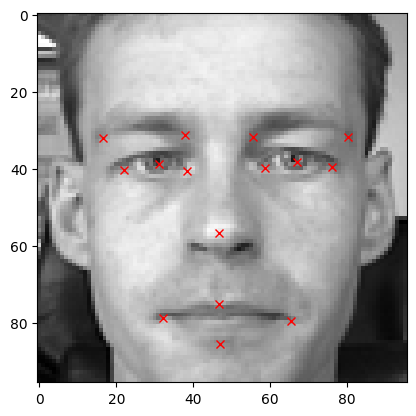

In [ ]:
# Plot a random image from the dataset along with facial keypoints.
# Image data is obtained from df['Image'] and plotted using plt.imshow
# 15 x and y coordinates for the corresponding image
# Since x-coordinates are in even columns (0,2,4,...) and y-coordinates are n odd columns (1,3,5,...)
# We access their value using .loc command, which get the values for coordinates of the image based on the column it is refering to.

i = np.random.randint(1, len(keyfacial_df)) # Random Number for a Random Image from the dataset
plt.imshow(keyfacial_df['Image'][i], cmap = 'gray') # Show Image
for j in range (1,31,2):
  plt.plot(keyfacial_df.loc[i][j-1], keyfacial_df.loc[i][j], 'rx') # Show Key Facial Points

/tmp/ipython-input-170370794.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(keyfacial_df.loc[i][j-1], keyfacial_df.loc[i][j], 'rx')


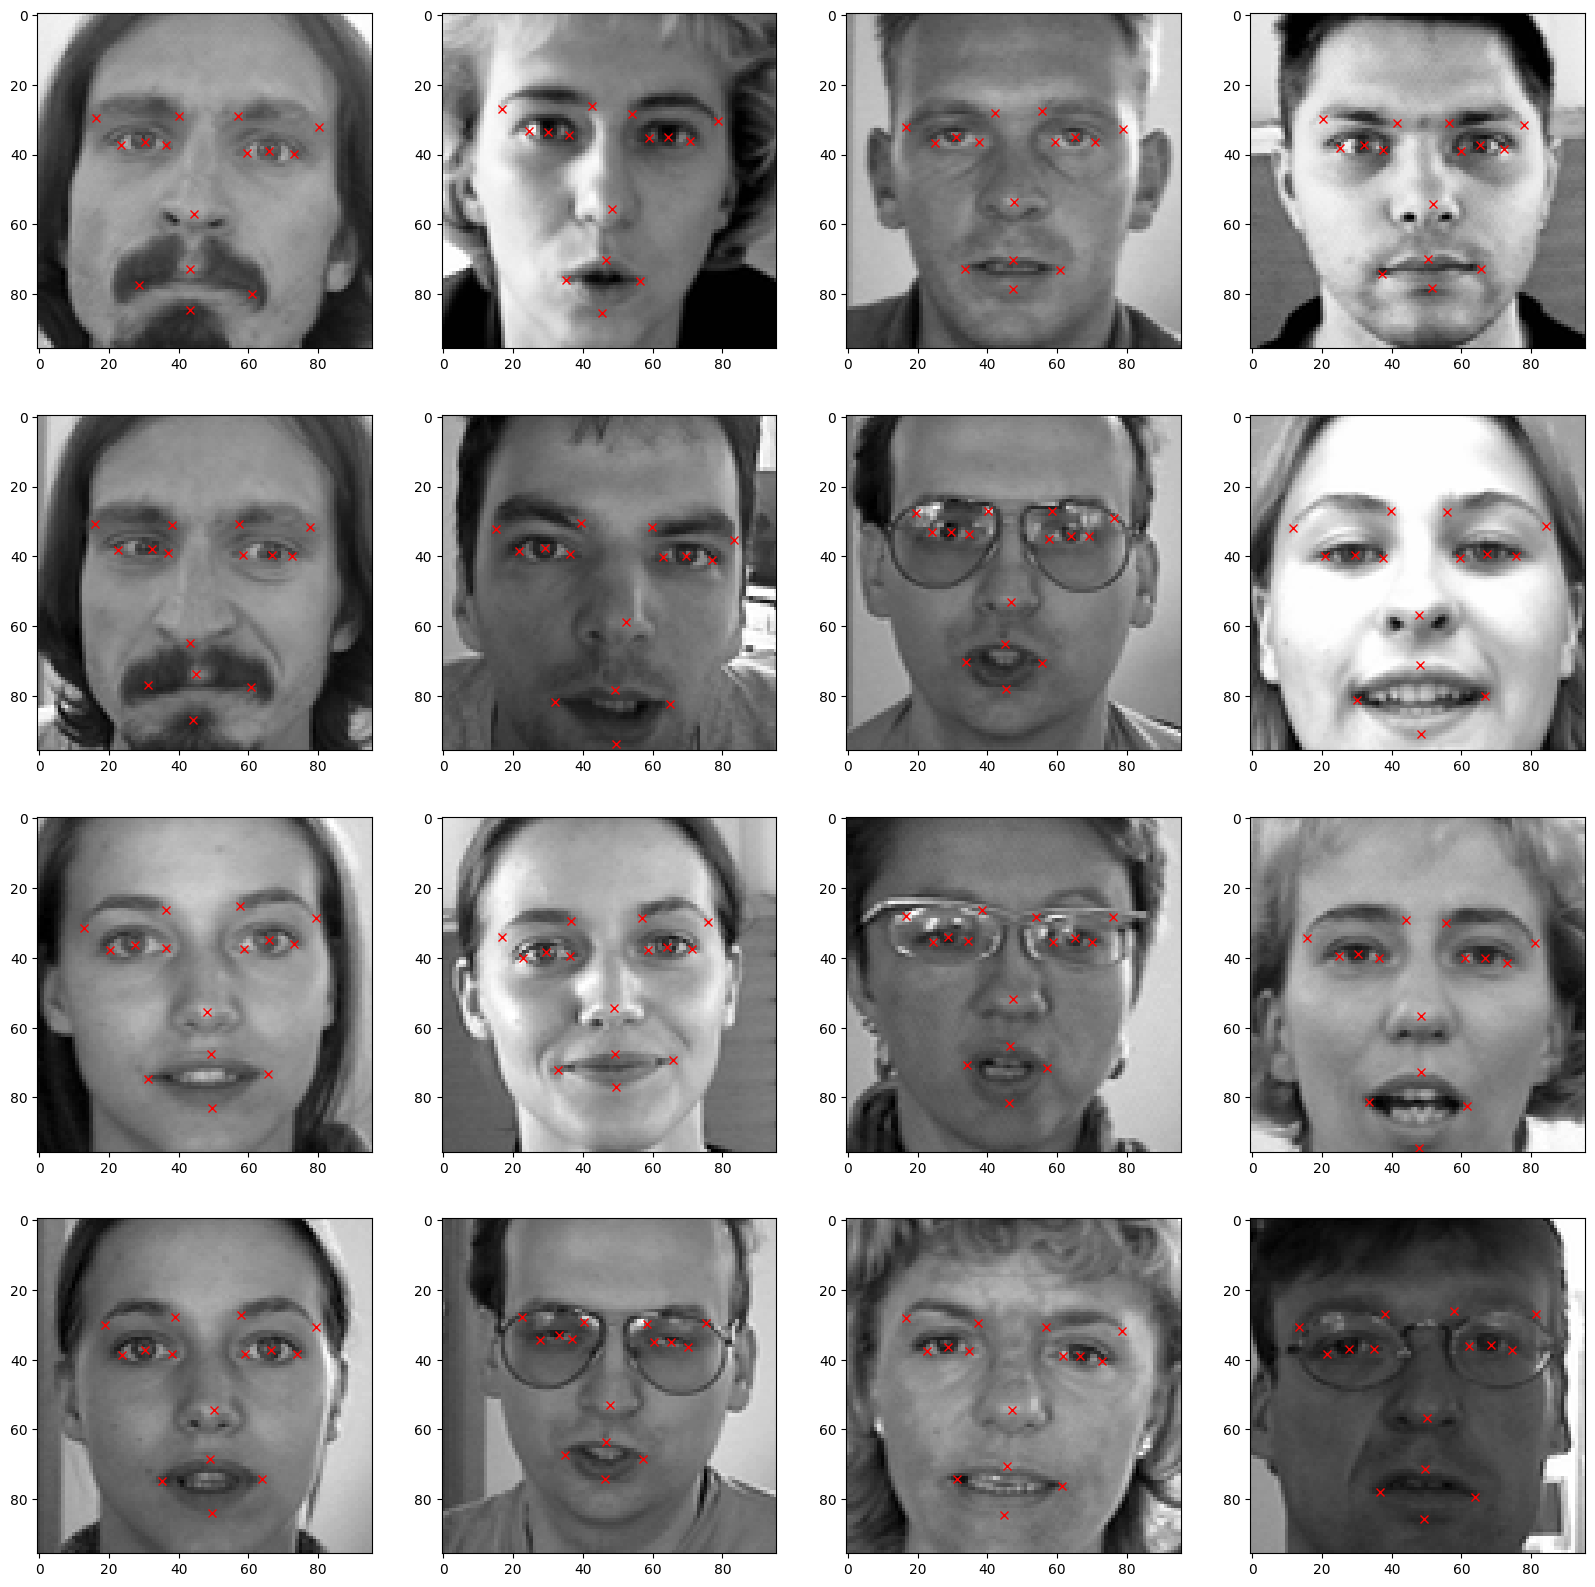

In [ ]:
# Let's view more images in a grid format
fig = plt.figure(figsize = (20, 20)) # Create a figure

for i in range(16):
  ax = fig.add_subplot(4, 4, i + 1) # Create Subplots
  image = plt.imshow(keyfacial_df['Image'][i], cmap = 'gray')
  for j in range (1, 31, 2):
    plt.plot(keyfacial_df.loc[i][j-1], keyfacial_df.loc[i][j], 'rx')


/tmp/ipython-input-3751922909.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(keyfacial_df.loc[x[i]][j-1], keyfacial_df.loc[x[i]][j], 'rx')


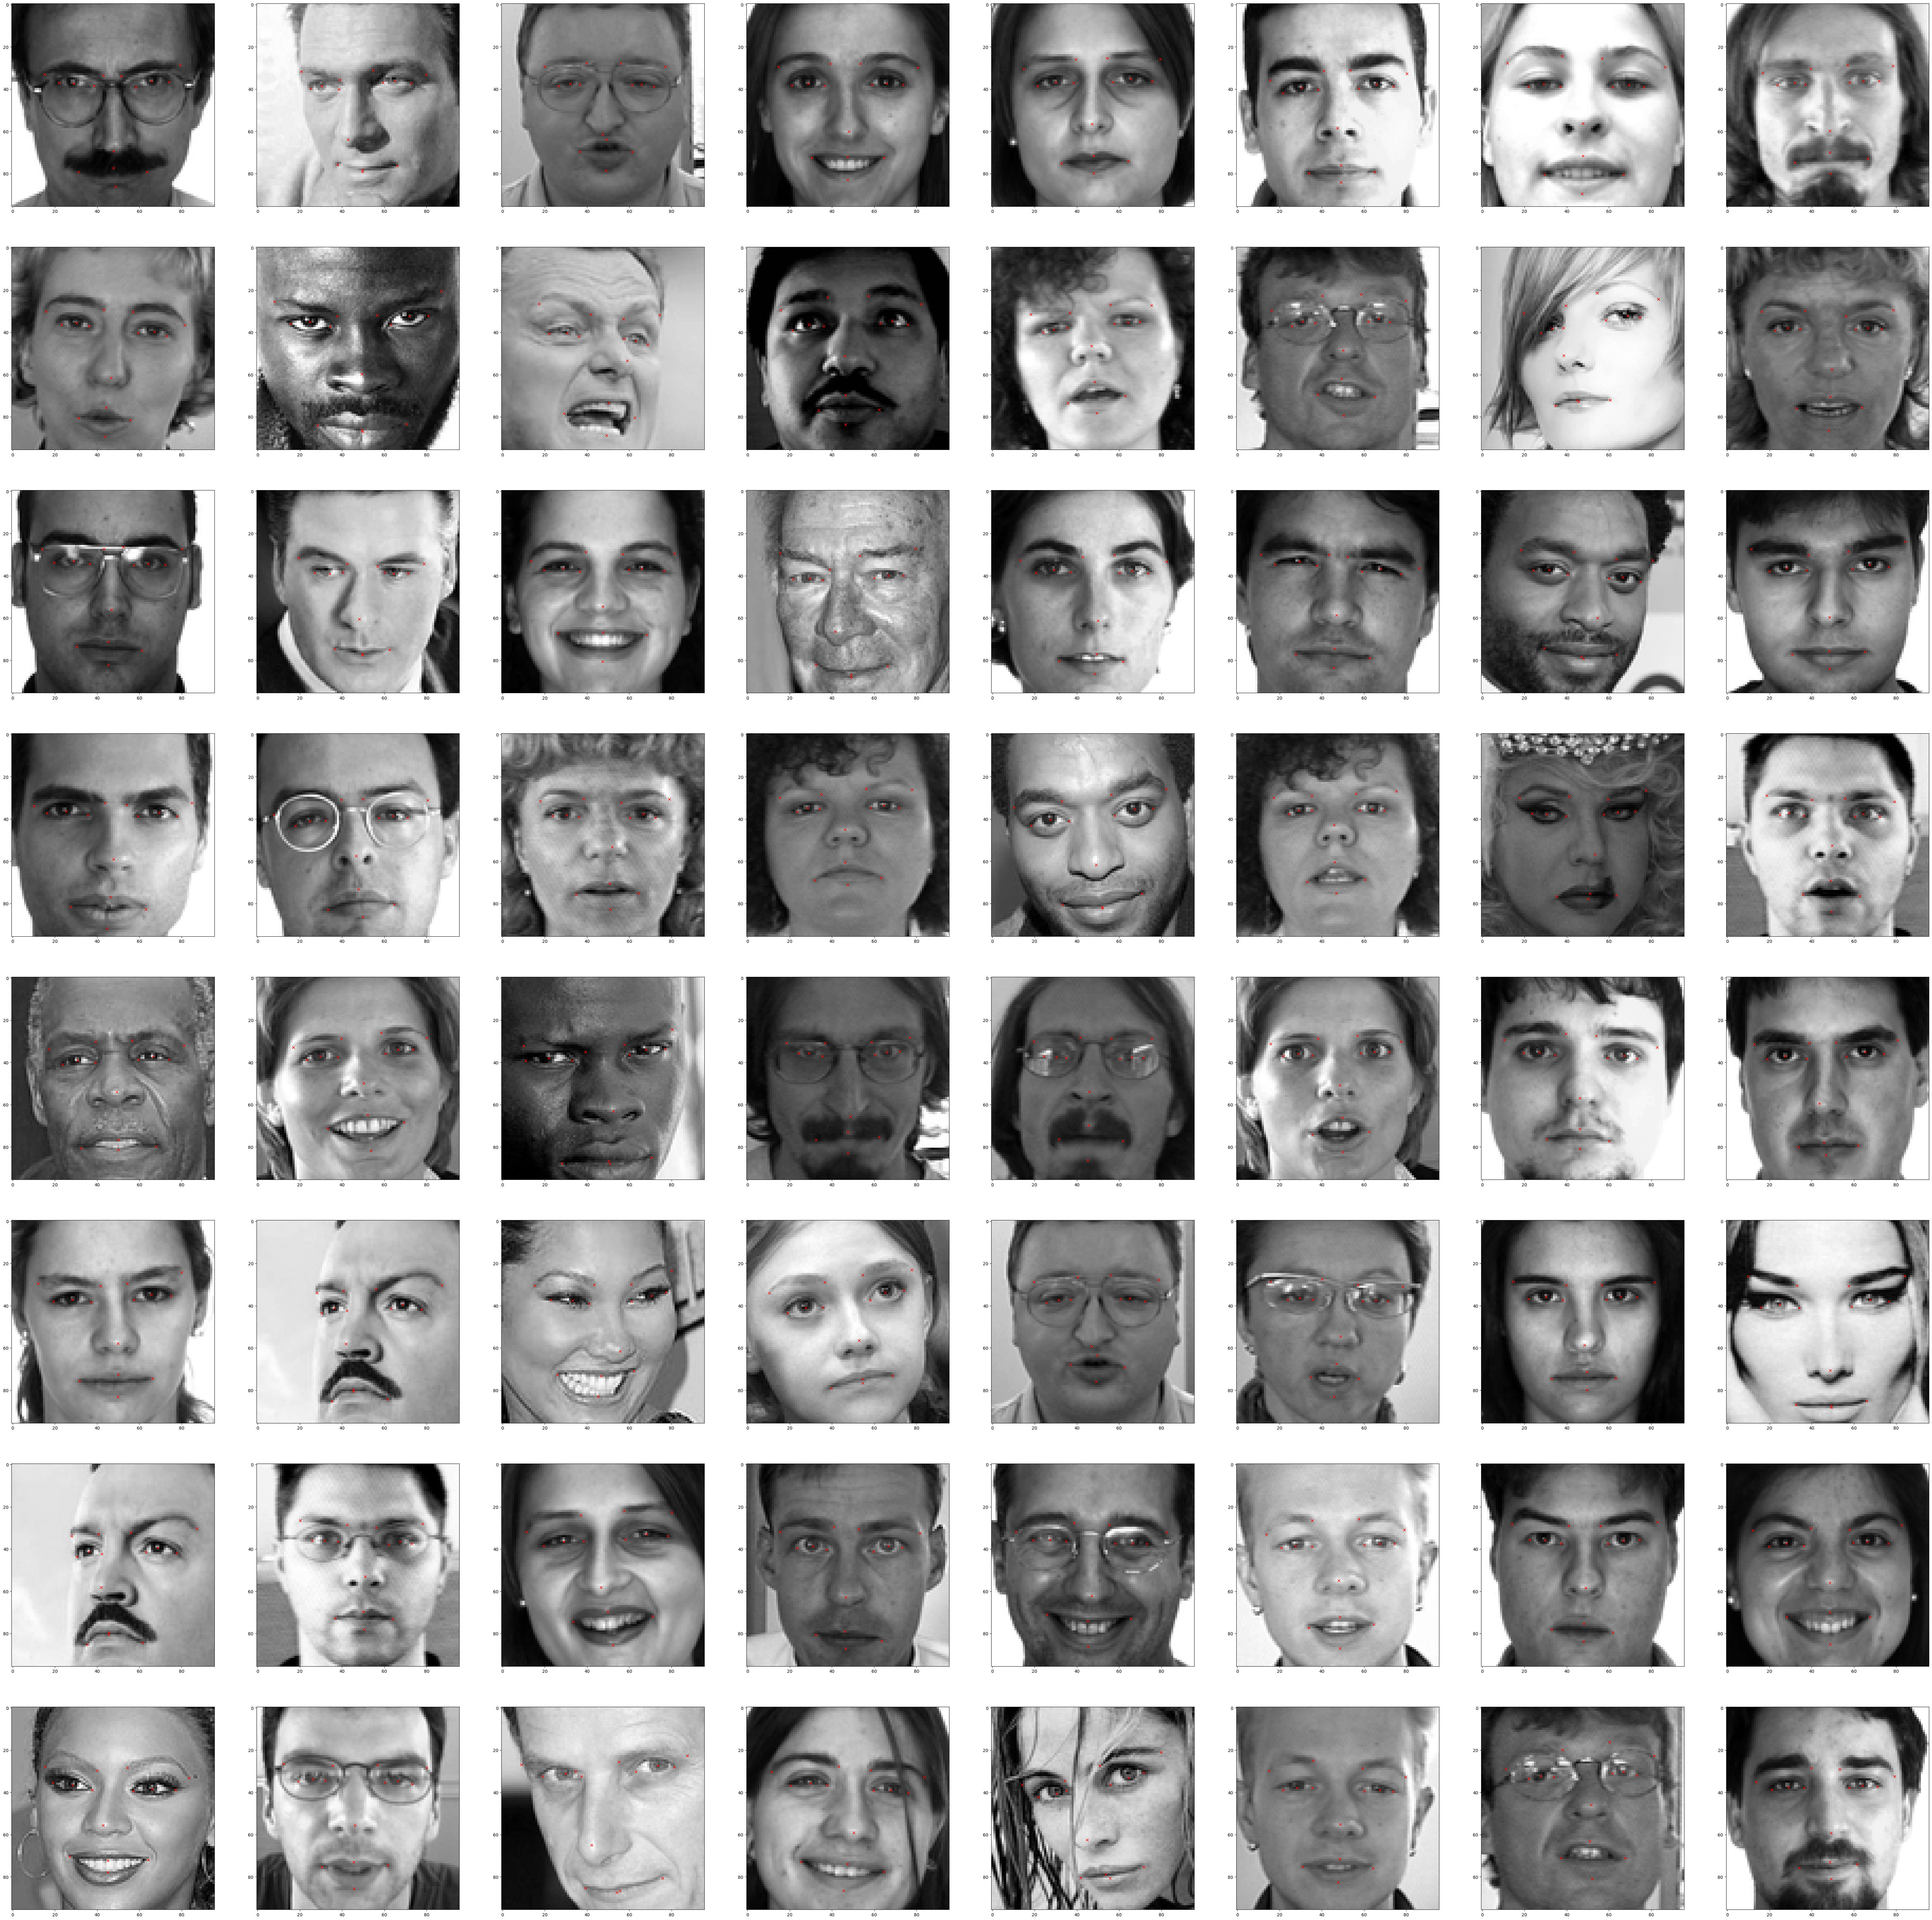

In [ ]:
fig = plt.figure(figsize = (80, 80)) # Create a figure
x = np.random.randint(1, len(keyfacial_df), size=(64))
for i in range(64):
  ax = fig.add_subplot(8, 8, i + 1) # Create Subplots
  image = plt.imshow(keyfacial_df['Image'][x[i]], cmap = 'gray')
  for j in range (1, 31, 2):
    plt.plot(keyfacial_df.loc[x[i]][j-1], keyfacial_df.loc[x[i]][j], 'rx')

## **TASK #3: PERFORM IMAGE AUGMENTATION**

In [ ]:
# Creat a new copy of the dataframe
import copy
keyfacial_df_copy = copy.copy(keyfacial_df)

In [ ]:
# Obtain the columns in the dataframe
columns = keyfacial_df_copy.columns[:-1]
columns

Index(['left_eye_center_x', 'left_eye_center_y', 'right_eye_center_x',
       'right_eye_center_y', 'left_eye_inner_corner_x',
       'left_eye_inner_corner_y', 'left_eye_outer_corner_x',
       'left_eye_outer_corner_y', 'right_eye_inner_corner_x',
       'right_eye_inner_corner_y', 'right_eye_outer_corner_x',
       'right_eye_outer_corner_y', 'left_eyebrow_inner_end_x',
       'left_eyebrow_inner_end_y', 'left_eyebrow_outer_end_x',
       'left_eyebrow_outer_end_y', 'right_eyebrow_inner_end_x',
       'right_eyebrow_inner_end_y', 'right_eyebrow_outer_end_x',
       'right_eyebrow_outer_end_y', 'nose_tip_x', 'nose_tip_y',
       'mouth_left_corner_x', 'mouth_left_corner_y', 'mouth_right_corner_x',
       'mouth_right_corner_y', 'mouth_center_top_lip_x',
       'mouth_center_top_lip_y', 'mouth_center_bottom_lip_x',
       'mouth_center_bottom_lip_y'],
      dtype='object')

In [ ]:
# Horizontal Flip - flip the images along y axis
keyfacial_df_copy['Image'] = keyfacial_df_copy['Image'].apply(lambda x: np.flip(x , axis = 1))

# Since we are flipping horizontally,  y-coordinate values would be the same
# Only x coordinate values would change, all we have to do is to substrac our initial x-coordinate values from width of the image
for i in range(len(columns)):
  if i%2 == 0:
    keyfacial_df_copy[columns[i]] = keyfacial_df_copy[columns[i]].apply(lambda x: 96. - float(x))

/tmp/ipython-input-694561677.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(keyfacial_df.loc[0][j-1], keyfacial_df.loc[0][j], 'rx')


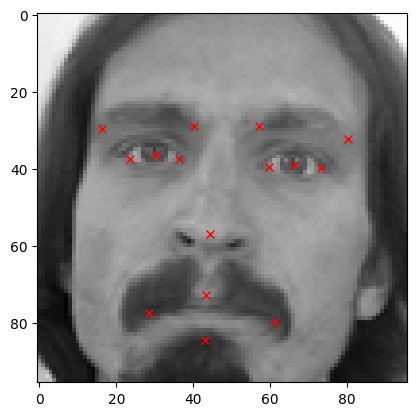

In [ ]:
# Show the Original Image
plt.imshow(keyfacial_df['Image'][0], cmap = 'gray')
for j in range(1, 31, 2):
  plt.plot(keyfacial_df.loc[0][j-1], keyfacial_df.loc[0][j], 'rx')

/tmp/ipython-input-2728298922.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(keyfacial_df_copy.loc[0][j-1], keyfacial_df_copy.loc[0][j], 'rx')


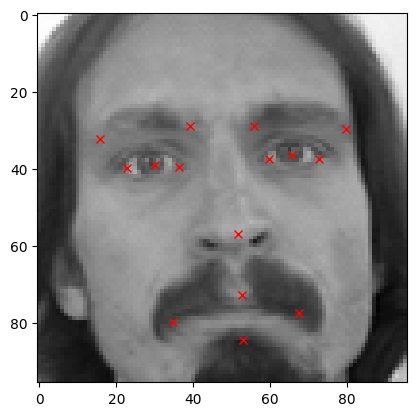

In [ ]:
# Show the Horizontally fliped image
plt.imshow(keyfacial_df_copy['Image'][0], cmap = 'gray')
for j in range(1, 31, 2):
  plt.plot(keyfacial_df_copy.loc[0][j-1], keyfacial_df_copy.loc[0][j], 'rx')

In [ ]:
# Concatenate the original dataframe with the augmented dataframe
augmented_df = np.concatenate((keyfacial_df, keyfacial_df_copy))

In [ ]:
augmented_df.shape

(4280, 31)

In [ ]:
# Randomingly increasing the brightness of the images
# We multiply pixel values by random values between 1.5 and 2 to increase the brightness of the Image
# We clip the value between 0 and 255

import random

keyfacial_df_copy = copy.copy(keyfacial_df)
keyfacial_df_copy['Image'] = keyfacial_df_copy['Image'].apply(lambda x: np.clip(random.uniform(1.5,2)*x, 0.0, 255.0))
augmented_df = np.concatenate((augmented_df, keyfacial_df_copy))
augmented_df.shape

(6420, 31)

/tmp/ipython-input-4218026135.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(keyfacial_df_copy.loc[0][j-1], keyfacial_df_copy.loc[0][j], 'rx')


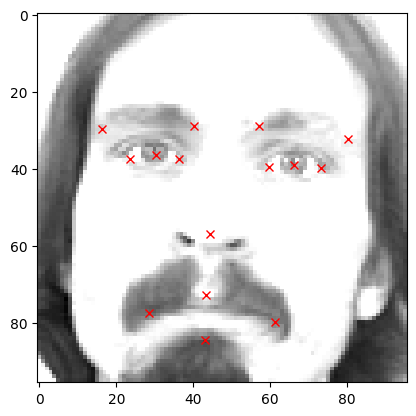

In [ ]:
# Show Image with increased brightness

plt.imshow(keyfacial_df_copy['Image'][0], cmap = 'gray')
for j in range(1, 31, 2):
  plt.plot(keyfacial_df_copy.loc[0][j-1], keyfacial_df_copy.loc[0][j], 'rx')

In [ ]:
# Vertical Flip - flip the images along x axis
keyfacial_df_copy = copy.copy(keyfacial_df)
keyfacial_df_copy['Image'] = keyfacial_df_copy['Image'].apply(lambda y: np.flip(y, axis = 0))

# Since we are flipping vertically, x-coordinate values would be the same
# Only y coordinate values would change, all we have to do is to substrac our initial y-coordinate values from width of the image
for i in range(len(columns)):
  if i%2 == 1:
    keyfacial_df_copy[columns[i]] = keyfacial_df_copy[columns[i]].apply(lambda y: 96. - float(y))

/tmp/ipython-input-987936525.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(keyfacial_df_copy.loc[0][j-1], keyfacial_df_copy.loc[0][j], 'rx')


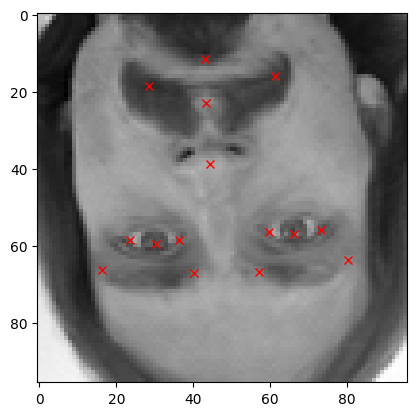

In [ ]:
# Show the Vertically fliped image
plt.imshow(keyfacial_df_copy['Image'][0], cmap = 'gray')
for j in range(1, 31, 2):
  plt.plot(keyfacial_df_copy.loc[0][j-1], keyfacial_df_copy.loc[0][j], 'rx')

In [ ]:
augmented_df = np.concatenate((augmented_df, keyfacial_df_copy))
augmented_df.shape

(8560, 31)

## **TASK #4: PERFORM DATA NORMALIZATION AND TRAINING DATA PREPARATION**

In [ ]:
# Obtain the values of images which is present in the 31st column (since index start from 0, we refer to 31st column by 30)
img = augmented_df[:,30]

# Normalize de images (Values in [0,1])
img = img/255.

# Create an empty array of shape (x, 96, 96, 1) to feed the model
X = np.empty((len(img), 96, 96, 1))

# Iterate through the img list and add image values to the empty array after expanding it's dimension from (96,96) to (96, 96, 1)
for i in range(len(img)):
  X[i,] = np.expand_dims(img[i], axis = 2)

# Convert the array type to float32
X = np.asarray(X).astype(np.float32)
X.shape

(8560, 96, 96, 1)

In [ ]:
# Obtain the Value of x & y coordinates which are to used as target
y = augmented_df[:,:30]
y = np.asarray(y).astype(np.float32)
y.shape

(8560, 30)

In [ ]:
# Split the data into train and test data (90% - Train, 10% - Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.1)

## **TASK #5: BUILD DEEP RESIDUAL NEURONAL NETWORK KEY FACIAL POINTS DETECTION MODEL**

In [ ]:
def res_block(X, filter, stage):

  ## Convolutional Block
  X_copy = X
  f1, f2, f3 = filter

  # Main Path
  X = Conv2D(f1, (1,1), strides = (1,1), name = 'res_' + str(stage) + '_conv_a', kernel_initializer = glorot_uniform(seed = 0))(X)
  #X = MaxPool2D((2,2))(X)
  X = BatchNormalization(axis = 3, name = 'bn_' + str(stage) + '_conv_a')(X)
  X = Activation('relu')(X)

  X = Conv2D(f2, kernel_size = (3,3), strides = (1,1), padding = 'same', name = 'res_' + str(stage) + '_conv_b', kernel_initializer = glorot_uniform(seed = 0))(X)
  X = BatchNormalization(axis = 3, name = 'bn_' + str(stage) + '_conv_b')(X)
  X = Activation('relu')(X)

  X = Conv2D(f3, kernel_size = (1,1), strides = (1,1), name = 'res_' + str(stage) + '_conv_c', kernel_initializer = glorot_uniform(seed = 0))(X)
  X = BatchNormalization(axis = 3, name = 'bn_' + str(stage) + '_conv_c')(X)

  # Short Path
  X_copy = Conv2D(f3, kernel_size = (1,1), strides = (1,1), name = 'res_' + str(stage) + '_conv_copy', kernel_initializer = glorot_uniform(seed = 0))(X_copy)
  #X_copy = MaxPool2D((2,2))(X_copy)
  X_copy = BatchNormalization(axis = 3, name = 'bn_' + str(stage) + '_conv_copy')(X_copy)

  # Add
  X = Add()([X, X_copy])
  X = Activation('relu')(X)

  ## Identity Block 1
  X_copy = X

  # Main Path
  X = Conv2D (f1, (1,1), strides = (1,1), name = 'res_' + str(stage) + '_identity_1_a', kernel_initializer = glorot_uniform(seed = 0))(X)
  X = BatchNormalization(axis = 3, name = 'bn_' + str(stage) + 'identity_block_1_a')(X)
  X = Activation('relu')(X)

  X = Conv2D(f2, kernel_size = (3,3), strides = (1,1), padding = 'same', name = 'res_' + str(stage) + 'identity_1_b', kernel_initializer = glorot_uniform(seed = 0))(X)
  X = BatchNormalization(axis = 3, name = 'bn_' + str(stage) + 'identity_1_b')(X)
  X = Activation('relu')(X)

  X = Conv2D(f3, kernel_size = (1,1), strides = (1,1), name = 'res_' + str(stage) + '_identity_1_c', kernel_initializer = glorot_uniform(seed = 0))(X)
  X = BatchNormalization(axis = 3, name = 'bn_' + str(stage) + '_identity_1_c')(X)

  # Add
  X = Add()([X, X_copy])
  X = Activation('relu')(X)

   ## Identity Block 2
  X_copy = X

  # Main Path
  X = Conv2D (f1, (1,1), strides = (1,1), name = 'res_' + str(stage) + '_identity_2_a', kernel_initializer = glorot_uniform(seed = 0))(X)
  X = BatchNormalization(axis = 3, name = 'bn_' + str(stage) + 'identity_block_2_a')(X)
  X = Activation('relu')(X)

  X = Conv2D(f2, kernel_size = (3,3), strides = (1,1), padding = 'same', name = 'res_' + str(stage) + 'identity_2_b', kernel_initializer = glorot_uniform(seed = 0))(X)
  X = BatchNormalization(axis = 3, name = 'bn_' + str(stage) + 'identity_2_b')(X)
  X = Activation('relu')(X)

  X = Conv2D(f3, kernel_size = (1,1), strides = (1,1), name = 'res_' + str(stage) + '_identity_2_c', kernel_initializer = glorot_uniform(seed = 0))(X)
  X = BatchNormalization(axis = 3, name = 'bn_' + str(stage) + '_identity_2_c')(X)

  # Add
  X = Add()([X, X_copy])
  X = Activation('relu')(X)

  return X

In [ ]:
input_shape = (96, 96, 1)

# Input Tensor Shape
X_input = Input(input_shape)

# Zero-Padding
X = ZeroPadding2D((3,3))(X_input)

# 1 - Stage
X = Conv2D(64, (7,7), strides = (2,2), name = 'conv1', kernel_initializer = glorot_uniform(seed = 0))(X)
X = BatchNormalization(axis = 3, name = 'bn_conv1')(X)
X = Activation('relu')(X)
X = MaxPooling2D((3,3), strides = (2,2))(X)

# 2 - Stage
X = res_block(X, filter = [64, 64, 256], stage = 2)

# 3 - Stage
X = res_block(X, filter = [128, 128, 512], stage = 3)

# Avarage Pooling
X = AveragePooling2D((2,2), name = 'Avarage_Pooling')(X)

# Final Layer
X = Flatten()(X)
X = Dense(4096, activation = 'relu')(X)
X = Dropout(0.2)(X)
X = Dense(2048, activation = 'relu')(X)
X = Dropout(0.1)(X)
X = Dense(30, activation = 'relu')(X)

model_1_facialKeyPoints = Model(inputs = X_input, outputs = X)
model_1_facialKeyPoints.summary()



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 96, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 102, 102,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 48, 48,    │      3,200 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_conv1            │ (None, 48, 48,    │        256 │ conv1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 48, 48,    │          0 │ bn_conv1[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 23, 23,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_2_conv_a        │ (None, 23, 23,    │      4,160 │ max_pooling2d[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2_conv_a         │ (None, 23, 23,    │        256 │ res_2_conv_a[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 23, 23,    │          0 │ bn_2_conv_a[0][0] │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_2_conv_b        │ (None, 23, 23,    │     36,928 │ activation_1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2_conv_b         │ (None, 23, 23,    │        256 │ res_2_conv_b[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 23, 23,    │          0 │ bn_2_conv_b[0][0] │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_2_conv_c        │ (None, 23, 23,    │     16,640 │ activation_2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_2_conv_copy     │ (None, 23, 23,    │     16,640 │ max_pooling2d[0]… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2_conv_c         │ (None, 23, 23,    │      1,024 │ res_2_conv_c[0][… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2_conv_copy      │ (None, 23, 23,    │      1,024 │ res_2_conv_copy[… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 23, 23,    │          0 │ bn_2_conv_c[0][0

 Total params: 263,383,070 (1004.73 MB)

 Trainable params: 263,374,494 (1004.69 MB)

 Non-trainable params: 8,576 (33.50 KB)

## **TASK #6: COMPILE AND TRAIN KEY FACIAL POINTS DETECTION DEEP LEARNING MODEL**

In [ ]:
adam = tf.keras.optimizers.Adam(
    learning_rate=0.0001,   # ← qué tan rápido aprende
    beta_1=0.9,             # ← momentum para gradientes
    beta_2=0.999,           # ← momentum para gradientes al cuadrado
    amsgrad=False           # ← variante más estable, aquí no necesaria
)

In [ ]:
huber = tf.keras.losses.Huber(delta=1.0)

In [ ]:
model_1_facialKeyPoints.compile(
    optimizer=adam,
    loss=huber,
    metrics=['mae']
)

In [ ]:
earlystopping = EarlyStopping(
    monitor='val_loss',         # ← lo que monitoreamos
    patience=50,                # ← cuántas épocas esperar
    restore_best_weights=True,  # ← vuelve al mejor modelo
    verbose=1
)

In [ ]:
checkpointer = ModelCheckpoint(
    filepath="FacialKeyPoints.weights.h5",
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

In [ ]:
history = model_1_facialKeyPoints.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=32,
    validation_split=0.2,          # ← divide el dataset automáticamente
    callbacks=[earlystopping, checkpointer],
    shuffle=True                   # ← IMPORTANTE para mezclar antes de dividir
)

Epoch 1/1000
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - loss: 13.7240 - mae: 14.2108
Epoch 1: val_loss improved from inf to 18.69639, saving model to FacialKeyPoints.weights.h5
193/193 ━━━━━━━━━━━━━━━━━━━━ 157s 669ms/step - loss: 13.7018 - mae: 14.1886 - val_loss: 18.6964 - val_mae: 19.1938
Epoch 2/1000
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 5.4626 - mae: 5.9395
Epoch 2: val_loss improved from 18.69639 to 9.50242, saving model to FacialKeyPoints.weights.h5
193/193 ━━━━━━━━━━━━━━━━━━━━ 138s 720ms/step - loss: 5.4611 - mae: 5.9379 - val_loss: 9.5024 - val_mae: 9.9920
Epoch 3/1000
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 4.5539 - mae: 5.0277
Epoch 3: val_loss improved from 9.50242 to 5.31799, saving model to FacialKeyPoints.weights.h5
193/193 ━━━━━━━━━━━━━━━━━━━━ 168s 872ms/step - loss: 4.5531 - mae: 5.0270 - val_loss: 5.3180 - val_mae: 5.8036
Epoch 4/1000
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 4.2406 - mae: 4.7141
Epoch 4: val_loss improved from 5.31799 t

In [ ]:
# Save the model architecture to json file for future use

model_json = model_1_facialKeyPoints.to_json()
with open("FacialKeyPoints-model.json", "w") as json_file:
  json_file.write(model_json)

## **TASK #7: ASSESS TRAINED KEY FACIAL POINTS DETECTION MODEL PERFORMANCE**

In [ ]:
with open('/content/drive/My Drive/Colab Notebooks/Modern AI Portfolio/Emotion AI/FacialKeyPoints-model.json', 'r') as json_file:
  json_savedModel = json_file.read()

# Load the model architecture
model_1_facialKeyPoints = tf.keras.models.model_from_json(json_savedModel)
model_1_facialKeyPoints.load_weights('/content/drive/My Drive/Colab Notebooks/Modern AI Portfolio/Emotion AI/FacialKeyPoints.weights.h5')

In [ ]:
adam = tf.keras.optimizers.Adam(
    learning_rate=0.0001,   # ← qué tan rápido aprende
    beta_1=0.9,             # ← momentum para gradientes
    beta_2=0.999,           # ← momentum para gradientes al cuadrado
    amsgrad=False           # ← variante más estable, aquí no necesaria
)

huber = tf.keras.losses.Huber(delta=1.0)
model_1_facialKeyPoints.compile(
    optimizer=adam,
    loss=huber,
    metrics=['mae']     # precisión para regresión
)

In [ ]:
# Evaluate the model
result = model_1_facialKeyPoints.evaluate(X_test, y_test, verbose=0)

test_loss = result[0]   # Huber loss en test
test_mae  = result[1]   # MAE en test

print(f"Test Loss (Huber): {test_loss:.4f}")
print(f"Test Mean Absolute Error (pixels): {test_mae:.4f}")


Test Loss (Huber): 1.9429
Test Mean Absolute Error (pixels): 2.3661


In [ ]:
# Get the model keys
history.history.keys()

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])

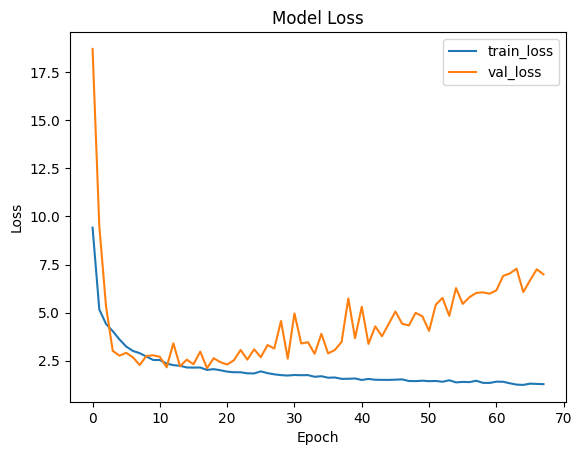

In [ ]:
# Plot the training artifacts
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train_loss', 'val_loss'], loc = 'upper right')
plt.show()

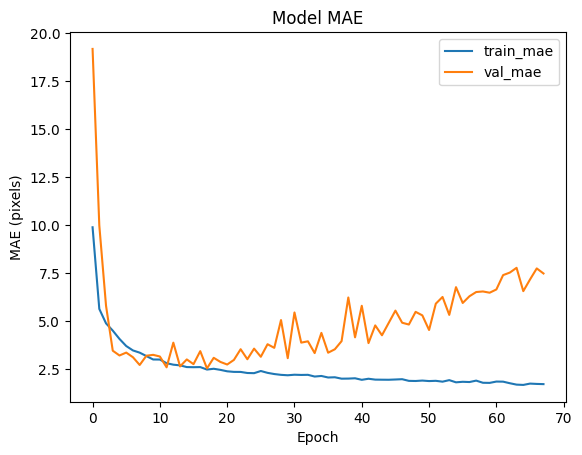

In [ ]:
# Plot MAE
plt.plot(history.history['mae'])
plt.plot(history.history['val_mae'])
plt.title('Model MAE')
plt.ylabel('MAE (pixels)')
plt.xlabel('Epoch')
plt.legend(['train_mae', 'val_mae'], loc='upper right')
plt.show()

# **PART 2. FACIAL EXPRESSION DETECTION**

## **TASK #8: IMPORT & EXPLORE DATASET FOR FACIAL EXPRESSION DETECTION**

In [ ]:
# Read the csv files for the facial expression data
facialexpression_df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/Modern AI Portfolio/Emotion AI/Datasets/icml_face_data.csv')

In [ ]:
facialexpression_df.head()

,emotion,pixels
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1,0,151 150 147 155 148 133 111 140 170 174 182 15...
2,2,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...
3,2,20 17 19 21 25 38 42 42 46 54 56 62 63 66 82 1...
4,3,77 78 79 79 78 75 60 55 47 48 58 73 77 79 57 5...


In [ ]:
facialexpression_df[' pixels'][0] # String format

'70 80 82 72 58 58 60 63 54 58 60 48 89 115 121 119 115 110 98 91 84 84 90 99 110 126 143 153 158 171 169 172 169 165 129 110 113 107 95 79 66 62 56 57 61 52 43 41 65 61 58 57 56 69 75 70 65 56 54 105 146 154 151 151 155 155 150 147 147 148 152 158 164 172 177 182 186 189 188 190 188 180 167 116 95 103 97 77 72 62 55 58 54 56 52 44 50 43 54 64 63 71 68 64 52 66 119 156 161 164 163 164 167 168 170 174 175 176 178 179 183 187 190 195 197 198 197 198 195 191 190 145 86 100 90 65 57 60 54 51 41 49 56 47 38 44 63 55 46 52 54 55 83 138 157 158 165 168 172 171 173 176 179 179 180 182 185 187 189 189 192 197 200 199 196 198 200 198 197 177 91 87 96 58 58 59 51 42 37 41 47 45 37 35 36 30 41 47 59 94 141 159 161 161 164 170 171 172 176 178 179 182 183 183 187 189 192 192 194 195 200 200 199 199 200 201 197 193 111 71 108 69 55 61 51 42 43 56 54 44 24 29 31 45 61 72 100 136 150 159 163 162 163 170 172 171 174 177 177 180 187 186 187 189 192 192 194 195 196 197 199 200 201 200 197 201 137 58 98 92

In [ ]:
# Function to convert pixel values in strin format to array format
def string2array(x):
  return np.array(x.split(' ')).reshape(48, 48, 1).astype('float32')

In [ ]:
facialexpression_df[' pixels'] = facialexpression_df[' pixels'].apply(lambda x: string2array(x))

In [ ]:
# Resize images from (48, 48) to (96, 96)
def resize(x):
  img = x.reshape(48, 48)
  return cv2.resize(img, dsize = (96, 96), interpolation = cv2.INTER_CUBIC)

In [ ]:
facialexpression_df[' pixels']= facialexpression_df[' pixels'].apply(lambda x: resize(x))

In [ ]:
facialexpression_df.head()

,emotion,pixels
0,0,"[[69.316925, 73.03865, 79.13719, 84.17186, 85...."
1,0,"[[151.09435, 150.91393, 150.65791, 148.96367, ..."
2,2,"[[23.061905, 25.50914, 29.47847, 33.99843, 36...."
3,2,"[[20.083221, 19.079437, 17.398712, 17.158691, ..."
4,3,"[[76.26172, 76.54747, 77.001785, 77.7672, 78.4..."


In [ ]:
# Check the shape of data frame
facialexpression_df.shape

(24568, 2)

In [ ]:
# Check for the presence of null values in the data frame
facialexpression_df.isnull().sum()

,0
emotion,0
pixels,0


In [ ]:
# Categories
label_to_text = {0:'anger', 1:'disgust', 2:'sad', 3:'happiness', 4:'surprise'}

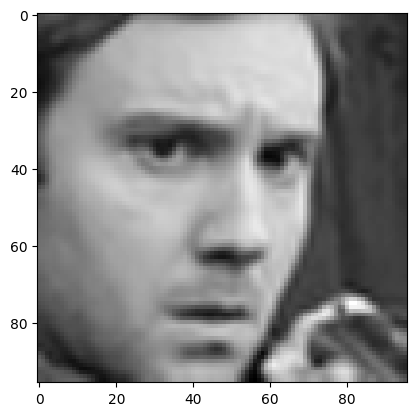

In [ ]:
# Show Image
plt.imshow(facialexpression_df[' pixels'][0], cmap = 'gray')

## **TASK #9: VISUALIZE IMAGES AND PLOT LABELS**

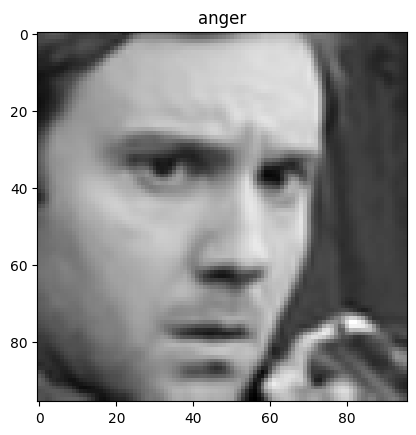

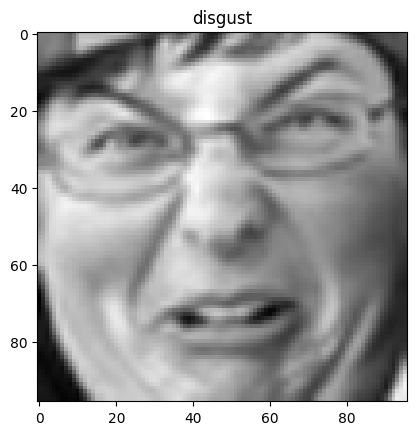

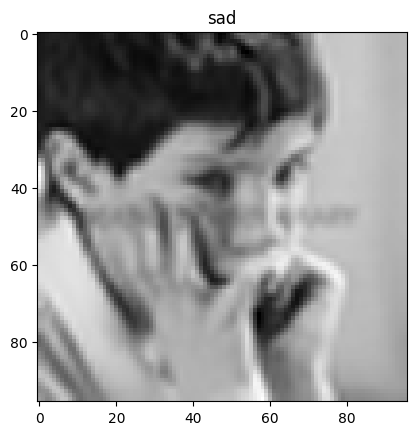

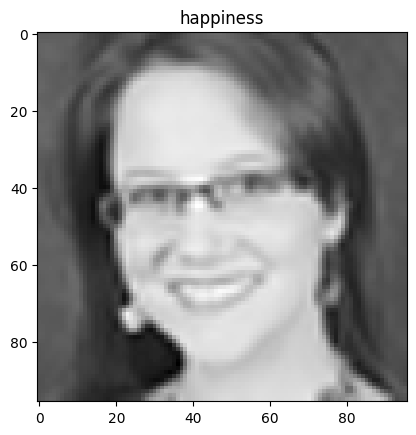

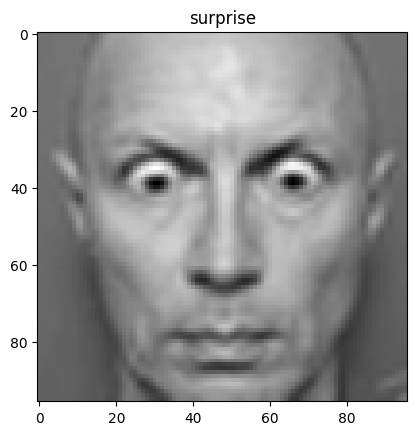

In [ ]:
emotions = [0, 1, 2, 3, 4]

for i in emotions:
  data = facialexpression_df[facialexpression_df['emotion'] == i][:1]
  img = data[' pixels'].item()
  img = img.reshape(96, 96)
  plt.figure()
  plt.title(label_to_text[i])
  plt.imshow(img, cmap = 'gray')

<Axes: xlabel='emotion', ylabel='count'>

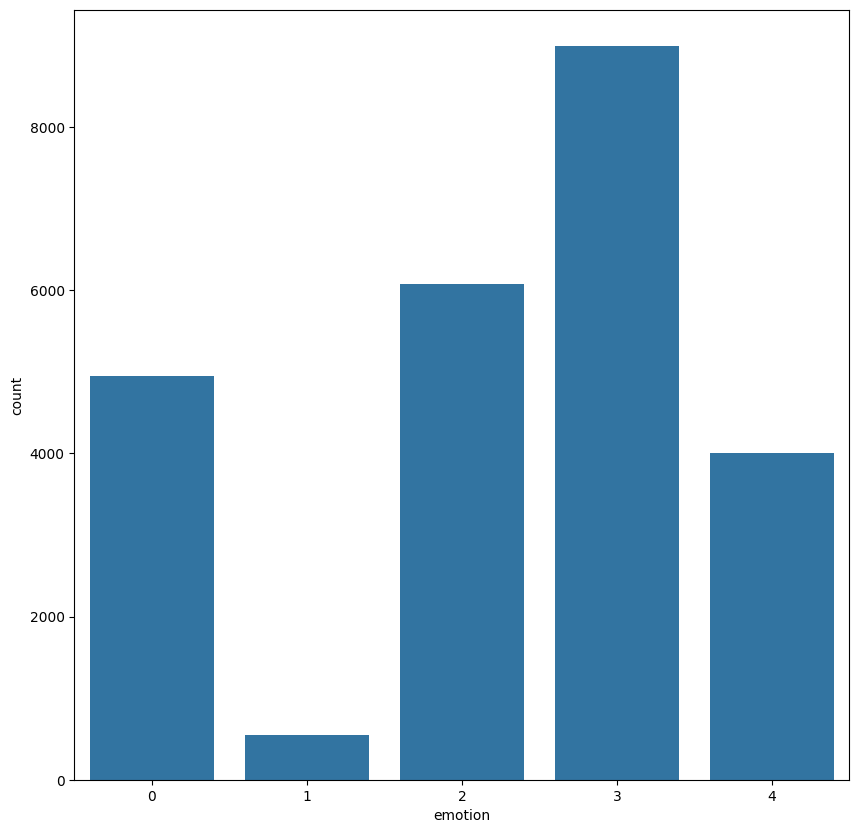

In [ ]:
# Check Emotions data set balance
plt.figure(figsize = (10,10))
sns.barplot(x = facialexpression_df.emotion.value_counts().index, y = facialexpression_df.emotion.value_counts())

## **TASK #10: PERFORM DATA PREPARATION AND IMAGE AUGMENTATION**

In [ ]:
# Split the datadrame in to features and labels
from keras.utils import to_categorical
X = facialexpression_df[' pixels']
y = to_categorical(facialexpression_df['emotion'])
X = np.stack(X, axis = 0)
X = X.reshape(24568, 96, 96, 1)

print(X.shape, y.shape)

(24568, 96, 96, 1) (24568, 5)


In [ ]:
# Split the data frame in to train, test and validation data frames
from sklearn.model_selection import train_test_split
X_train, X_Test, y_train, y_Test = train_test_split(X, y, test_size = 0.1, shuffle = True)
X_val, X_Test, y_val, y_Test = train_test_split(X_Test, y_Test, test_size = 0.5, shuffle = True)

In [ ]:
# Image Pre-Processing
X_train = X_train/255
X_val = X_val/255
X_Test = X_Test/255

In [ ]:
train_datagen = ImageDataGenerator(
    rotation_range = 15,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    shear_range = 0.1,
    zoom_range = 0.1,
    horizontal_flip = True,
    fill_mode = "nearest"
)

## **TASK #11: BUILD AND TRAIN DEEP LEARNING MODEL FOR FACIAL EXPRESSION CLASSIFICATION**

In [ ]:
input_shape = (96, 96, 1)

# Input Tensor Shape
X_input = Input(input_shape)

# Zero Padding
X = ZeroPadding2D((3,3))(X_input)

# 1-Stage
X = Conv2D(64, (7,7), strides = (2,2), name = 'conv1', kernel_initializer = glorot_uniform(seed = 0))(X)
X = BatchNormalization(axis = 3, name = 'bn_conv1')(X)
X = Activation('relu')(X)
X = MaxPooling2D((3,3), strides = (2,2))(X)

# 2-Stage
X = res_block(X, filter = [64,64,256], stage = 2)

# 3-Stage
X = res_block(X, filter = [128,128,512], stage = 3)

# 4-Stage
X = res_block(X, filter = [256,256,1024], stage = 4)

# Average Pooling
X = AveragePooling2D((4,4), name = 'Average_Pooling')(X)

# Final Layer
X = Flatten()(X)
X = Dense(5, activation = 'softmax', name = 'Dense_final', kernel_initializer = glorot_uniform(seed = 0))(X)

model_2_emotion = Model(inputs = X_input, outputs = X, name = 'Resnet18')
model_2_emotion.summary()

Model: "Resnet18"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 96, 96, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 102, 102,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 48, 48,    │      3,200 │ zero_padding2d_1… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_conv1            │ (None, 48, 48,    │        256 │ conv1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_19       │ (None, 48, 48,    │          0 │ bn_conv1[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 23, 23,    │          0 │ activation_19[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_2_conv_a        │ (None, 23, 23,    │      4,160 │ max_pooling2d_1[… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2_conv_a         │ (None, 23, 23,    │        256 │ res_2_conv_a[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (None, 23, 23,    │          0 │ bn_2_conv_a[0][0] │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_2_conv_b        │ (None, 23, 23,    │     36,928 │ activation_20[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2_conv_b         │ (None, 23, 23,    │        256 │ res_2_conv_b[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_21       │ (None, 23, 23,    │          0 │ bn_2_conv_b[0][0] │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_2_conv_c        │ (None, 23, 23,    │     16,640 │ activation_21[0]… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_2_conv_copy     │ (None, 23, 23,    │     16,640 │ max_pooling2d_1[… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2_conv_c         │ (None, 23, 23,    │      1,024 │ res_2_conv_c[0][… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2_conv_copy      │ (None, 23, 23,    │      1,024 │ res_2_conv_copy[… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 23, 23,    │          0 │ bn_2_conv_c[0][0

 Total params: 5,063,173 (19.31 MB)

 Trainable params: 5,043,333 (19.24 MB)

 Non-trainable params: 19,840 (77.50 KB)

In [ ]:
# Train the Network
model_2_emotion.compile(optimizer = "Adam", loss = "categorical_crossentropy", metrics = ["accuracy"])

In [ ]:
# Using early stopping to exit training if validation loss is not decreasing even after certain epochs (patience)
earlystopping = EarlyStopping(monitor = 'val_loss', mode = 'min', verbose = 1, patience = 50)

# Save best model
checkpointer = ModelCheckpoint(filepath = "FacialExpression_weights.h5", verbose = 1, save_best_only = True)

In [ ]:
history = model_2_emotion.fit(train_datagen.flow(X_train, y_train, batch_size = 64),
                              validation_data = (X_val,y_val), steps_per_epoch = len(X_train)//64,
                              epochs = 1000, callbacks=[checkpointer, earlystopping])

Epoch 1/1000
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.5219 - loss: 1.1494
Epoch 1: val_loss improved from inf to 1.09610, saving model to FacialExpression_weights.h5


345/345 ━━━━━━━━━━━━━━━━━━━━ 116s 334ms/step - accuracy: 0.5220 - loss: 1.1492 - val_accuracy: 0.5163 - val_loss: 1.0961
Epoch 2/1000
  1/345 ━━━━━━━━━━━━━━━━━━━━ 2:03 358ms/step - accuracy: 0.6406 - loss: 0.8638

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_loss did not improve from 1.09610
345/345 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6406 - loss: 0.8638 - val_accuracy: 0.5090 - val_loss: 1.0982
Epoch 3/1000
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.6217 - loss: 0.9545
Epoch 3: val_loss improved from 1.09610 to 0.87274, saving model to FacialExpression_weights.h5


345/345 ━━━━━━━━━━━━━━━━━━━━ 110s 318ms/step - accuracy: 0.6217 - loss: 0.9544 - val_accuracy: 0.6450 - val_loss: 0.8727
Epoch 4/1000
  1/345 ━━━━━━━━━━━━━━━━━━━━ 1:57 342ms/step - accuracy: 0.6094 - loss: 1.0626
Epoch 4: val_loss did not improve from 0.87274
345/345 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6094 - loss: 1.0626 - val_accuracy: 0.6401 - val_loss: 0.8736
Epoch 5/1000
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.6511 - loss: 0.8680
Epoch 5: val_loss improved from 0.87274 to 0.82057, saving model to FacialExpression_weights.h5


...

345/345 ━━━━━━━━━━━━━━━━━━━━ 109s 315ms/step - accuracy: 0.8132 - loss: 0.5016 - val_accuracy: 0.7801 - val_loss: 0.5654
Epoch 50/1000
  1/345 ━━━━━━━━━━━━━━━━━━━━ 1:57 343ms/step - accuracy: 0.7500 - loss: 0.6137
Epoch 50: val_loss did not improve from 0.56541
345/345 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7500 - loss: 0.6137 - val_accuracy: 0.7777 - val_loss: 0.5879
Epoch 51/1000
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.8146 - loss: 0.4813
Epoch 51: val_loss did not improve from 0.56541
345/345 ━━━━━━━━━━━━━━━━━━━━ 107s 309ms/step - accuracy: 0.8146 - loss: 0.4813 - val_accuracy: 0.7736 - val_loss: 0.6027
Epoch 52/1000
  1/345 ━━━━━━━━━━━━━━━━━━━━ 1:38 287ms/step - accuracy: 0.7656 - loss: 0.5399
Epoch 52: val_loss did not improve from 0.56541
345/345 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7656 - loss: 0.5399 - val_accuracy: 0.7679 - val_loss: 0.6091
Epoch 53/1000
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.8268 - loss: 0.4709
Epoch 53: va

345/345 ━━━━━━━━━━━━━━━━━━━━ 109s 315ms/step - accuracy: 0.8336 - loss: 0.4433 - val_accuracy: 0.7891 - val_loss: 0.5473
Epoch 60/1000
  1/345 ━━━━━━━━━━━━━━━━━━━━ 2:02 356ms/step - accuracy: 0.8594 - loss: 0.4775
Epoch 60: val_loss did not improve from 0.54730
345/345 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8594 - loss: 0.4775 - val_accuracy: 0.7801 - val_loss: 0.5727
Epoch 61/1000
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.8367 - loss: 0.4362
Epoch 61: val_loss improved from 0.54730 to 0.54054, saving model to FacialExpression_weights.h5


345/345 ━━━━━━━━━━━━━━━━━━━━ 109s 315ms/step - accuracy: 0.8367 - loss: 0.4363 - val_accuracy: 0.8013 - val_loss: 0.5405
Epoch 62/1000
  1/345 ━━━━━━━━━━━━━━━━━━━━ 2:06 367ms/step - accuracy: 0.7812 - loss: 0.5840
Epoch 62: val_loss improved from 0.54054 to 0.54003, saving model to FacialExpression_weights.h5


345/345 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7812 - loss: 0.5840 - val_accuracy: 0.7989 - val_loss: 0.5400
Epoch 63/1000
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.8334 - loss: 0.4372
Epoch 63: val_loss improved from 0.54003 to 0.51655, saving model to FacialExpression_weights.h5


345/345 ━━━━━━━━━━━━━━━━━━━━ 109s 315ms/step - accuracy: 0.8334 - loss: 0.4372 - val_accuracy: 0.8054 - val_loss: 0.5166
Epoch 64/1000
  1/345 ━━━━━━━━━━━━━━━━━━━━ 1:53 331ms/step - accuracy: 0.7500 - loss: 0.5509
Epoch 64: val_loss did not improve from 0.51655
345/345 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7500 - loss: 0.5509 - val_accuracy: 0.8086 - val_loss: 0.5185
Epoch 65/1000
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.8413 - loss: 0.4213
Epoch 65: val_loss did not improve from 0.51655
345/345 ━━━━━━━━━━━━━━━━━━━━ 107s 309ms/step - accuracy: 0.8413 - loss: 0.4213 - val_accuracy: 0.6889 - val_loss: 0.7592
Epoch 66/1000
  1/345 ━━━━━━━━━━━━━━━━━━━━ 1:40 293ms/step - accuracy: 0.8281 - loss: 0.5220
Epoch 66: val_loss did not improve from 0.51655
345/345 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8281 - loss: 0.5220 - val_accuracy: 0.7166 - val_loss: 0.7025
Epoch 67/1000
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.8432 - loss: 0.4163
Epoch 67: va

In [ ]:
# Saving the model architecture
model_json = model_2_emotion.to_json()
with open("FacialExpression-model.json", "w") as json_file:
  json_file.write(model_json)

## **TASK #12: ASSESS THE PERFORMANCE OF TRAINED FACIAL EXPRESSION CLASSIFIER MODEL**

In [ ]:
with open('/content/drive/My Drive/Colab Notebooks/Modern AI Portfolio/Emotion AI/FacialExpression-model.json', 'r') as json_file:
  json_savedModel = json_file.read()

# Load the model architecture
model_2_emotion = tf.keras.models.model_from_json(json_savedModel)
model_2_emotion.load_weights('/content/drive/My Drive/Colab Notebooks/Modern AI Portfolio/Emotion AI/FacialExpression_weights.h5')
model_2_emotion.compile(loss = "categorical_crossentropy", optimizer = "Adam", metrics = ['accuracy'])

In [ ]:
score = model_2_emotion.evaluate(X_Test, y_Test)
print('Test Accuracy: {}'.format(score[1]))

In [ ]:
history.history.keys()

In [ ]:
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

In [ ]:
epochs = range(len(accuracy))

plt.plot(epochs, accuracy, 'bo', label = 'Training Accuracy')
plt.plot(epochs, val_accuracy, 'b', label = 'Validation Accuracy')
plt.title('Training and Validation Loss')
plt.legend()

In [ ]:
plt.plot(epochs, loss, 'ro', label = 'Training Loss')
plt.plot(epochs, val_loss, 'r', label = 'Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()

In [ ]:
# Predicted Model
predicted_classes = np.argmax(model_2_emotion.predict(X_Test), axis = -1)
y_true = np.argmax(y_Test, axis = -1)
print(y_true.shape)

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, predicted_classes)
plt.figure(figsize = (10, 10))
sns.heatmap(cm, annot = True, cbar = False)

In [ ]:
L = 5
W = 5

fig, axes = plt.subplots(L, W, figsize = (24,24))
axes = axes.ravel()

for i in np.arange(0, L*W):
  axes[i].imshow(X_test[i].reshape(96, 96), cmap = 'gray')
  axes[i].set_title('Prediction = {}\n True = {}'.format(label_to_text[predicted_classes[i]], label_to_text[y_true[i]]))
  axes[i].axis('off')

plt.subplots_adjust(wspace = 1)

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_true, predicted_classes))

# **PART 3. COMBINE BOTH FACIAL EXPRESSION AND KEY POINTS DETECTION MODELS**

## **TASK #13: COMBINE MODELS**

In [ ]:
def predict(X_test):

  # Making prediction from the keypoint model
  df_predict = model_1_facialKeyPoints.predict(X_test)

  # Making prediction from the emotion model
  df_emotion = np.argmax(model_2_emotion.predict(X_test), axis = -1)

  # Reshaping array from (856,) to (856,1)
  df_emotion = np.expand_dims(df_emotion, axis = 1)

  # Converting the predictions into a data frame
  df_predict = pd.DataFrame(df_predict, columns = columns)

  # Adding emotion into the predicted dataframe
  df_predict['emotion'] = df_emotion

  return df_predict

In [ ]:
df_predict = predict(X_Test)

In [ ]:
df_predict.head()

In [ ]:
# Plotting the test images and their predicted keypoints end emotions
fig, axes = plt.subplots(4, 4, figsize = (24,24))
axes = axes.ravel()

for i in range (16):
  axes[i].imshow(X_test[i].squeeze(), cmap = 'gray')
  axes[i].set_title('Prediction = {}'.format(label_to_text[df_predict['emotion'][i]]))
  axes[i].axis('off')
  for j in range(1, 31, 2):
    axes[i].plot(df_predict.loc[i][j-1], df_predict.loc[i][j], 'rx')